In [16]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

def f_constant0(input):
    return 0
def f_constant1(input):
    return 1
def f_balanced0(input):
    return 0 if input == 0 else 1
def f_balanced1(input):
    return 1 if input == 0 else 0

#Oracle blackbox
def create_oracle(function_choice):
    if function_choice == 0:
        return
    elif function_choice == 1:
        qc.cx(0,1)
    elif function_choice == 2:
        qc.cx(0,1)
        qc.x(1)
    elif function_choice == 3:
        qc.x(1)

def print_function_type(circuit_output): #Argument of this function is known to the user but not to the algorithm
    return "constant" if circuit_output == {'0': 1} else "balanced"


qc = QuantumCircuit(2,1)


In [17]:
qc.h(0)
qc.x(1)
qc.h(1)
qc.save_statevector(label="|α⟩")

create_oracle(3) #CHANGE PARAMETER TO CHANGE FUNCTION
qc.save_statevector(label="|β⟩")

qc.h(0)
qc.save_statevector(label="|γ⟩")
qc.measure(0,0)

        

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

The function is constant


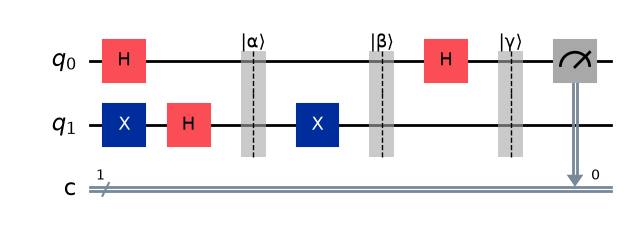

In [18]:
#Run simulated version of the quantum circuit just built
#Deutsch's algorithm returns function type with probability 1. So one measurement is enough (one shot)
result = AerSimulator().run(qc, shots = 1).result() 

pi1 = result.data()["|α⟩"]
pi2 = result.data()["|β⟩"]
pi3 = result.data()["|γ⟩"]

display(pi1.draw("latex"))
display(pi2.draw("latex"))
display(pi3.draw("latex"))

print("The function is", print_function_type(result.get_counts()))

qc.draw('mpl')